In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures, OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import make_pipeline

In [2]:
FILE_PATH = "/content/drive/MyDrive/AIO 2024/Module_4/Week 4/T4/data/SalesPrediction.csv"

# **Đọc và hiển thị bộ DL, Các thông tin cơ bản của bộ DL**

In [3]:
df = pd.read_csv(FILE_PATH)
df.head()

,TV,Radio,Social Media,Influencer,Sales
0,16.0,6.566231,2.907983,Mega,54.732757
1,13.0,9.237765,2.409567,Mega,46.677897
2,41.0,15.886446,2.913410,Mega,150.177829
3,83.0,30.020028,6.922304,Mega,298.246340
4,15.0,8.437408,1.405998,Micro,56.594181


In [4]:
# Lấy các thông tin cơ bản của bộ DL

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4572 entries, 0 to 4571
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            4562 non-null   float64
 1   Radio         4568 non-null   float64
 2   Social Media  4566 non-null   float64
 3   Influencer    4572 non-null   object 
 4   Sales         4566 non-null   float64
dtypes: float64(4), object(1)
memory usage: 178.7+ KB


In [6]:
df.describe()

,TV,Radio,Social Media,Sales
count,4562.000000,4568.000000,4566.000000,4566.000000
mean,54.066857,18.160356,3.323956,192.466602
std,26.125054,9.676958,2.212670,93.133092
min,10.000000,0.000684,0.000031,31.199409
25%,32.000000,10.525957,1.527849,112.322882
50%,53.000000,17.859513,3.055565,189.231172
75%,77.000000,25.649730,4.807558,272.507922
max,100.000000,48.871161,13.981662,364.079751


# **Mã hóa cột có dL là categori**

In [7]:
Encode = OrdinalEncoder()

In [8]:
Encode.fit(df[['Influencer']])

OrdinalEncoder()

In [9]:
df['Influencer'] = Encode.transform(df[['Influencer']])

# **fill các giá trị Nan trong bộ DL hoặc xóa bỏ các giá trị Nan**

In [10]:
df.isnull().sum()

,0
TV,10
Radio,4
Social Media,6
Influencer,0
Sales,6


In [11]:
df.dropna(inplace=True)

In [12]:
# Kiểm tra lại thông tin của bộ DL
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4546 entries, 0 to 4571
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            4546 non-null   float64
 1   Radio         4546 non-null   float64
 2   Social Media  4546 non-null   float64
 3   Influencer    4546 non-null   float64
 4   Sales         4546 non-null   float64
dtypes: float64(5)
memory usage: 213.1 KB


# **Vẽ biểu đồ boxplot các đặc trưng của bộ DL**

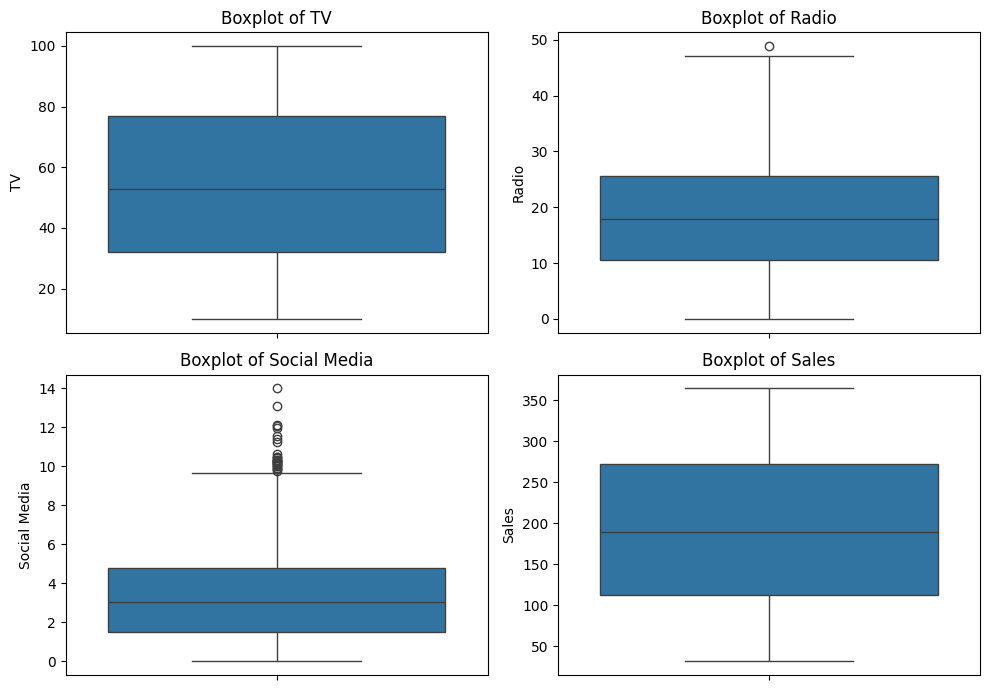

In [13]:
numerical_cols = ['TV', 'Radio', 'Social Media', 'Sales']

plt.figure(figsize=(10, 7))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 2, i + 1) # Arrange plots in a 2x2 grid
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

# **Vẽ biểu đồ thế hiện giữa các biến đặc trưng và biến mục tiêu**

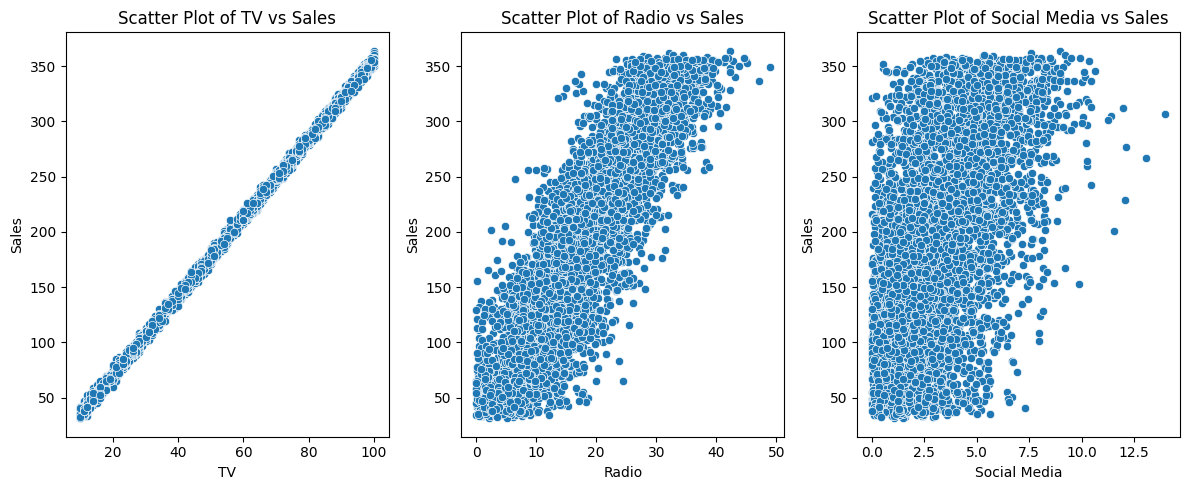

In [14]:
feature_cols = ['TV', 'Radio', 'Social Media']
target_col = 'Sales'

plt.figure(figsize=(12, 5))
for i, col in enumerate(feature_cols):
    plt.subplot(1, 3, i + 1) # Arrange plots in a 1x3 grid
    sns.scatterplot(x=df[col], y=df[target_col])
    plt.title(f'Scatter Plot of {col} vs {target_col}')
    plt.xlabel(col)
    plt.ylabel(target_col)
plt.tight_layout()
plt.show()

# **Xác định mối tương quan giữa các biến bằng hệ số tương quan Correlation coefficent**

In [15]:
df.corr()

,TV,Radio,Social Media,Influencer,Sales
TV,1.000000,0.869158,0.527687,-0.013724,0.999497
Radio,0.869158,1.000000,0.606338,-0.010696,0.868638
Social Media,0.527687,0.606338,1.000000,-0.020689,0.527446
Influencer,-0.013724,-0.010696,-0.020689,1.000000,-0.014067
Sales,0.999497,0.868638,0.527446,-0.014067,1.000000


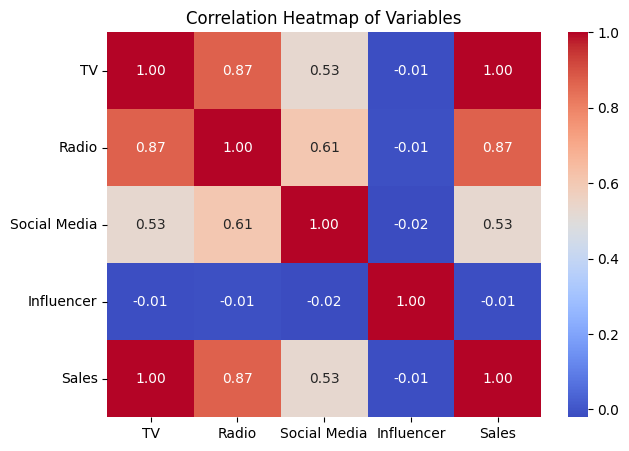

In [16]:
# vẽ biểu đồ heat map thể hiện mối tương quan giữa các biến
plt.figure(figsize=(7, 5))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Variables')
plt.show()

# **Xóa Cột Influencer do không có mối quan hệ gì với biến mục tiêu**

In [17]:
df.drop(columns=['Influencer'], inplace=True)

# **Chuẩn hóa DL các cột DL**

In [18]:
# Lấy các đặc trưng và nhãn của bộ DL
X = df.iloc[:,:-1]
y = df.iloc[:,-1]

In [19]:
scaler = MinMaxScaler()

In [20]:
# Chuẩn các cột đặc trưng của bộ DL
X = scaler.fit_transform(X)

In [21]:
X

array([[0.06666667, 0.13434587, 0.20798371],
       [0.03333333, 0.18901147, 0.17233583],
       [0.34444444, 0.32505846, 0.20837189],
       ...,
       [0.37777778, 0.40514007, 0.36448971],
       [0.67777778, 0.35878423, 0.1388137 ],
       [0.35555556, 0.32670038, 0.36093904]])

In [22]:
y = y.to_numpy()
y

array([ 54.73275715,  46.67789698, 150.1778288 , ..., 163.6314574 ,
       253.6104113 , 148.2024141 ])

# **Chia bộ DL thành tập training và tập testing**

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [24]:
X_train.shape

(3636, 3)

In [25]:
X_test.shape

(910, 3)

In [26]:
# Nên chuyển về vector dạng cột -> chuyển về dạng ma trận N dòng 1 cột -> Chuẩn với toán học
class LinearRegressionCustom:
    def __init__(self,lr = 0.01, batch_size = 1, epochs = 100, shuffle = False):
        self.lr = lr # learning rate
        self.batch_size = batch_size # num sample to training
        self.epochs = epochs # epoch: Number of times the model is learned in all data
        self.shuffle = shuffle # allow shuffle data in each epoch
        self.w = None
        self.Nfeature = None # number of feature of data train
        self.Nsample = None # number of sample of data train
        self.Losses = [] # List of loss of each epoch
    def checkDim(self,X):
        if X.ndim == 1:
            raise ValueError("X must be 2 Dimensional")
        return 1
    # add feature have value = 1 on head each sample
    def addfeature1(self,X):
        if self.checkDim(X):
            if X.shape[1] == self.Nfeature + 1: return X
            else:
                feature1 = np.ones((X.shape[0],1))
                return np.concatenate((feature1,X),axis = 1)
    # function predict
    def predict(self,X):
        X = self.addfeature1(X)
        return X@self.w

    # Compute Loss
    def compute_loss(self,y_pred,y):
        return np.mean((y_pred-y)**2)/2

    # Compute gradient Loss with w
    # Loss = 1/2m *(y_pred-y)^2 -> m is bacth_size
    def dL_dw(self,y_pred,y,X):
        return X.T@(y_pred - y)*1/X.shape[0] # / for X.shape[0] because the sample of X != batch_size

    # function training model
    def fit(self,X,y):
        self.Nsample, self.Nfeature = X.shape
        # add feature 1 for X
        X = self.addfeature1(X)
        y = y.reshape(-1,1)
        self.w = np.random.uniform(-1,1,size = (self.Nfeature+1,1))# w is matrix have shape (Nfeatur,1) - vector column
        data_train = np.concatenate((X,y),axis = 1)
        for epoch in range(self.epochs):
            if self.shuffle: np.random.shuffle(data_train)
            Loss = [] # Loss of 1 epoch
            for i in range(0,self.Nsample,self.batch_size):
                batch = data_train[i:i+self.batch_size]
                X_train, ytrain = batch[:,:-1], batch[:,-1].reshape(-1,1)
                y_pred = self.predict(X_train)
                loss = self.compute_loss(y_pred,ytrain)
                Loss.append(loss) # append loss of each batch
                dL_dw = self.dL_dw(y_pred,ytrain,X_train)
                self.w -= self.lr*dL_dw
            self.Losses.append(sum(Loss)/len(Loss))
            print(f"epoch: {epoch+1:<5} ====== Loss = {self.Losses[-1].item():<10.4f} =============== w = {str(self.w.reshape(1,-1)):<20}")

# **======================= Linear Regressionn ========================**

In [27]:
rg = LinearRegressionCustom(lr=0.09,batch_size=512, epochs=800, shuffle=True)

In [28]:
rg.fit(X_train,y_train)

epoch: 1     ====== Loss = 11320.6704 =============== w = [[86.93743728 58.54212891 43.06090104 24.86060411]]
epoch: 2     ====== Loss = 2503.6675  =============== w = [[110.72498286  82.88532903  59.08797414  33.7199154 ]]
epoch: 3     ====== Loss = 1488.4519  =============== w = [[113.77020199  95.5302292   66.26756965  37.07992504]]
epoch: 4     ====== Loss = 1279.9681  =============== w = [[110.60039345 104.29080915  70.55509671  38.53032334]]
epoch: 5     ====== Loss = 1124.8366  =============== w = [[106.51804764 111.85874389  74.09097847  39.62593316]]
epoch: 6     ====== Loss = 1031.2492  =============== w = [[102.33146922 118.97691352  77.31259153  40.4400263 ]]
epoch: 7     ====== Loss = 924.4335   =============== w = [[ 97.45721773 125.18711368  79.90307723  40.9563417 ]]
epoch: 8     ====== Loss = 842.1489   =============== w = [[ 93.67872045 131.48930035  82.55861598  41.53070402]]
epoch: 9     ====== Loss = 742.9519   =============== w = [[ 89.3571516  136.99538862  84.83

In [29]:
y_pred_train = rg.predict(X_train)
y_pred_test = rg.predict(X_test)

In [30]:
print(y_pred_test.shape)
print(y_test.shape)

(910, 1)
(910,)


In [31]:
y_pred_test = y_pred_test.flatten()
y_pred_train = y_pred_train.flatten()

In [32]:
print(y_pred_test.shape)
print(y_test.shape)

(910,)
(910,)


# **Đánh giá độ chính xác của mô hình Linear Regrssion**

In [33]:
print(f"MSE- mean square error training set: {mean_squared_error(y_train, y_pred_train)}")
print(f"MSE- mean square error testing set: {mean_squared_error(y_test, y_pred_test)}")
print(f"RMSE - Root mean square error training set: {root_mean_squared_error(y_pred_train,y_train)}")
print(f"RMSE - Root mean square error testing set: {root_mean_squared_error(y_pred_test,y_test)}")
print(f"R2- score training set: {r2_score(y_train, y_pred_train):.4f}")
print(f"R2- score testing set: {r2_score(y_test, y_pred_test):.4f}")

MSE- mean square error training set: 8.90051149799356
MSE- mean square error testing set: 8.454285317433978
RMSE - Root mean square error training set: 2.9833725040620656
RMSE - Root mean square error testing set: 2.9076253743276452
R2- score training set: 0.9990
R2- score testing set: 0.9990


In [34]:
# sử dụng mô hình Linear Regression của sklearn
rg = LinearRegression()

In [35]:
rg.fit(X_train,y_train)

LinearRegression()

In [36]:
y_pred_test = rg.predict(X_test)
y_pred_train = rg.predict(X_train)

In [37]:
print(f"MSE- mean square error training set: {mean_squared_error(y_train, y_pred_train)}")
print(f"MSE- mean square error testing set: {mean_squared_error(y_test, y_pred_test)}")
print(f"RMSE - Root mean square error training set: {root_mean_squared_error(y_pred_train,y_train)}")
print(f"RMSE - Root mean square error testing set: {root_mean_squared_error(y_pred_test,y_test)}")
print(f"R2- score training set: {r2_score(y_train, y_pred_train):.4f}")
print(f"R2- score testing set: {r2_score(y_test, y_pred_test):.4f}")

MSE- mean square error training set: 8.78886116566086
MSE- mean square error testing set: 8.321632226629537
RMSE - Root mean square error training set: 2.964601350208972
RMSE - Root mean square error testing set: 2.8847239428807634
R2- score training set: 0.9990
R2- score testing set: 0.9990


# **=================== Polynomial Regression =====================**

In [38]:
tranform_feature = PolynomialFeatures(degree=2, include_bias=False, interaction_only=False )

In [39]:
# Feature trước khi biến đổi
X.shape[1]

3

In [40]:
X_poly = tranform_feature.fit_transform(X)

In [41]:
# Feature sau khi biến đổi
X_poly.shape[1]

9

In [55]:
X_poly[:5]

array([[0.06666667, 0.13434587, 0.20798371, 0.00444444, 0.00895639,
        0.01386558, 0.01804881, 0.02794175, 0.04325722],
       [0.03333333, 0.18901147, 0.17233583, 0.00111111, 0.00630038,
        0.00574453, 0.03572533, 0.03257345, 0.02969964],
       [0.34444444, 0.32505846, 0.20837189, 0.11864198, 0.11196458,
        0.07177254, 0.105663  , 0.06773305, 0.04341885],
       [0.81111111, 0.61426337, 0.49509766, 0.65790123, 0.49823585,
        0.40157921, 0.37731949, 0.30412036, 0.24512169],
       [0.05555556, 0.17263436, 0.10055814, 0.00308642, 0.0095908 ,
        0.00558656, 0.02980262, 0.01735979, 0.01011194]])

In [49]:
X_train, X_test, y_train, y_test = train_test_split(X_poly, y, test_size=0.2, random_state=42)

# **Khởi tạo và huấn luyện mô hình hồi quy đa thức**

In [50]:
model = LinearRegressionCustom(lr=0.1,batch_size=512, epochs=800, shuffle=True)

In [51]:
model.fit(X_train,y_train)

epoch: 1     ====== Loss = 8893.1166  =============== w = [[81.28125323 55.3126609  39.72469861 24.13814637 42.08871761 28.28465025
  17.31557094 20.90015325 12.24065443  9.22565688]]
epoch: 2     ====== Loss = 997.3693   =============== w = [[94.39646559 70.3595307  48.85733464 28.67758109 54.50960949 36.45413079
  21.78179552 26.30525006 15.14312038 10.98948664]]
epoch: 3     ====== Loss = 570.1451   =============== w = [[93.68472167 76.86910234 51.64385386 29.21694852 60.63598005 40.08282864
  23.46277885 28.28654768 15.95383129 11.22033632]]
epoch: 4     ====== Loss = 465.3310   =============== w = [[90.14326702 80.77760548 52.612576   28.67867834 64.59159868 42.16541751
  24.21532673 29.13989879 16.07617857 10.97784906]]
epoch: 5     ====== Loss = 399.4281   =============== w = [[86.57027575 83.9994917  53.24113795 27.98467789 67.87229807 43.80184188
  24.73144691 29.70939356 16.05598492 10.65360685]]
epoch: 6     ====== Loss = 358.7350   =============== w = [[83.30778551 86.88577

# **Vẽ loss của mô hình**

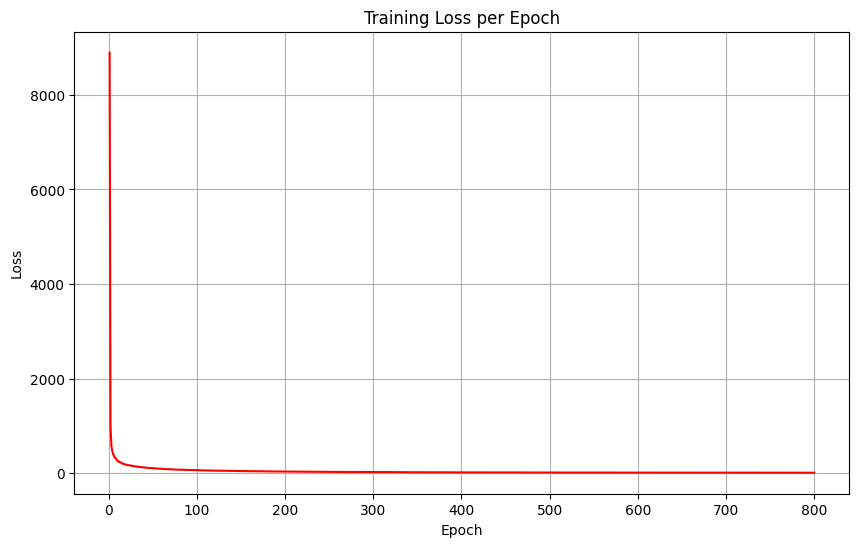

In [52]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(model.Losses) + 1), model.Losses, linestyle='-', color='r')
plt.title('Training Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

In [53]:
y_pred = model.predict(X_test)

In [54]:
print(f"MSE- mean square error training set: {mean_squared_error(y_pred, y_test)}")
print(f"R2- score testing set: {r2_score(y_test, y_pred):.4f}")

MSE- mean square error training set: 12.766327518246086
R2- score testing set: 0.9985


# **Chỉ biến đổi polynomailFeature với đặc trưng social media có mức độ tương quan thấp**

In [56]:
tranform_feature = PolynomialFeatures(degree=2, include_bias=False, interaction_only=False)

In [57]:
social_media_poly_feature = tranform_feature.fit_transform(X[:,-1].reshape(-1,1))

In [58]:
X_poly = np.concatenate((X[:,:-1],social_media_poly_feature),axis=1)

In [71]:
X_poly.shape

(4546, 4)

In [59]:
X_train, X_test, y_train, y_test = train_test_split(X_poly, y, test_size=0.2, random_state=42)

In [67]:
model = LinearRegressionCustom(lr=0.1,batch_size=512, epochs=850, shuffle=True)

In [68]:
model.fit(X_train,y_train)

epoch: 1     ====== Loss = 10502.0880 =============== w = [[91.2656768  62.37660642 45.04998128 25.7650699  10.21848687]]
epoch: 2     ====== Loss = 2234.7000  =============== w = [[112.08915518  86.66366041  60.66449111  34.21046016  13.82034328]]
epoch: 3     ====== Loss = 1390.5284  =============== w = [[112.77105978  98.95168275  67.33680518  36.88359567  15.2149032 ]]
epoch: 4     ====== Loss = 1198.8370  =============== w = [[108.67793221 108.03024326  71.76675304  38.29789009  16.1745195 ]]
epoch: 5     ====== Loss = 1072.0761  =============== w = [[103.5267112  115.75204738  75.03042153  38.9347827   16.73864008]]
epoch: 6     ====== Loss = 950.8386   =============== w = [[ 98.31689717 122.80075742  77.9281769   39.4783597   17.23204707]]
epoch: 7     ====== Loss = 836.8187   =============== w = [[ 94.03374608 129.59417292  80.76608231  39.98534508  17.67535153]]
epoch: 8     ====== Loss = 766.7337   =============== w = [[ 89.34545857 135.88063267  83.2876354   40.38045021  18.

In [69]:
y_pred = model.predict(X_test)

In [70]:
print(f"MSE- mean square error training set: {mean_squared_error(y_pred, y_test)}")
print(f"R2- score testing set: {r2_score(y_test, y_pred):.4f}")

MSE- mean square error training set: 8.3441413291018
R2- score testing set: 0.9990
